#Model Training

**Models trained:**
1. MLP Baseline
2. 1D CNN with FiLM conditioning (proposed)
3. 1D CNN + Self-Attention (enhanced)

Training is restricted to the attached-flow design envelope AoA ∈ [-2°, 10°] An `envelope.json` is saved for inference time OOD detection in Notebook 3.

In [ ]:
!pip install -q torch torchvision matplotlib numpy pandas scikit-learn tqdm

In [ ]:
import json
import pickle as pkl
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

_LOCAL_DIR = Path('/content/airfoil_data')
_DRIVE_DIR = Path('/content/drive/My Drive/airfoil_surrogate')
_OUTPUT_DIR = Path('/content/model_outputs')
_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Model outputs → {_OUTPUT_DIR}')

Device: cuda
GPU: NVIDIA L4
Model outputs → /content/model_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/airfoil_surrogate-20260428T054106Z-3-001.zip" -d "/content/airfoil_data"

Archive:  /content/airfoil_surrogate-20260428T054106Z-3-001.zip
  inflating: /content/airfoil_data/airfoil_surrogate/names_test.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/X_val.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/dataset_stats.json  
  inflating: /content/airfoil_data/airfoil_surrogate/names_train.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/y_val.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/airfoil_dataset_labeled.pkl  
  inflating: /content/airfoil_data/airfoil_surrogate/xfoil_checkpoint.pkl  
  inflating: /content/airfoil_data/airfoil_surrogate/y_train.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/X_test.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/airfoil_dataset_raw.pkl  
  inflating: /content/airfoil_data/airfoil_surrogate/airfoil_dataset_final.pkl  
  inflating: /content/airfoil_data/airfoil_surrogate/X_train.npy  
  inflating: /content/airfoil_data/airfoil_surrogate/names_val.npy  
  i

In [ ]:
def _p(filename: str) -> Path:
    local = _LOCAL_DIR / filename
    return local if local.exists() else _DRIVE_DIR / filename

X_train_raw = np.load(_p('X_train.npy'))
y_train_raw = np.load(_p('y_train.npy'))
X_val_raw   = np.load(_p('X_val.npy'))
y_val_raw   = np.load(_p('y_val.npy'))
X_test_raw  = np.load(_p('X_test.npy'))
y_test_raw  = np.load(_p('y_test.npy'))

X_geom_train_raw = np.load(_p('X_geom_train.npy'))
X_geom_val_raw   = np.load(_p('X_geom_val.npy'))
X_geom_test_raw  = np.load(_p('X_geom_test.npy'))

df_full = pd.read_pickle(_p('airfoil_dataset_final.pkl'))

with open(_p('dataset_stats.json')) as f:
    _stats = json.load(f)

N_POINTS = _stats['n_resample_points']   # 200
INPUT_DIM = _stats['input_dim']           # 402  (raw MLP input)
GEOM_DIM = _stats.get('geom_input_dim', 209)  # 209  (CNN input: 200 + 5 + 2 + 2)
N_GRID = 100   # chord stations in thickness/camber distributions

print(f'Loaded from: {_p("X_train.npy").parent}')
print(f'Raw shapes  — train {X_train_raw.shape}, val {X_val_raw.shape}, test {X_test_raw.shape}')
print(f'Geom shapes — train {X_geom_train_raw.shape}, val {X_geom_val_raw.shape}')
print(f'N_POINTS={N_POINTS}, INPUT_DIM={INPUT_DIM}, GEOM_DIM={GEOM_DIM}')


Loaded from: /content/drive/My Drive/airfoil_surrogate
Raw shapes  — train (6489, 402), val (1414, 402), test (1381, 402)
Geom shapes — train (6489, 207), val (1414, 207)
N_POINTS=200, INPUT_DIM=402, GEOM_DIM=207


## 3. In-Distribution Filtering (Addressing OOD Problem)

Per instructor feedback: neural surrogates degrade badly out-of-distribution.
We restrict to the **attached-flow design envelope** before training:

| Variable | Min | Max | Rationale |
|----------|-----|-----|-----------|
| AoA | -2° | 10° | Attached flow; XFOIL reliable |
| CL | -0.5 | 3.0 | Removes stall outliers |
| CD | 0.001 | 0.06 | Removes non-physical drag values |

The excluded samples are saved as the OOD test set for Notebook 3.

In [ ]:
#design envelope
AOA_MIN, AOA_MAX = -2.0, 10.0
CL_MIN, CL_MAX = -0.5, 3.0
CD_MIN, CD_MAX =  0.001, 0.06
RE_MIN, RE_MAX = 500_000, 2_000_000

ENVELOPE = {
    'aoa_min': AOA_MIN, 'aoa_max': AOA_MAX,
    'CL_min':  CL_MIN,  'CL_max':  CL_MAX,
    'CD_min':  CD_MIN,  'CD_max':  CD_MAX,
    'reynolds_min': RE_MIN, 'reynolds_max': RE_MAX,
}

def make_mask(df_split: pd.DataFrame) -> np.ndarray:
    return (
        (df_split['aoa'] >= AOA_MIN) & (df_split['aoa'] <= AOA_MAX) &
        (df_split['CL']  >= CL_MIN)  & (df_split['CL']  <= CL_MAX)  &
        (df_split['CD']  >= CD_MIN)  & (df_split['CD']  <= CD_MAX)
    ).values

df_train = df_full[df_full['split'] == 'train'].reset_index(drop=True)
df_val = df_full[df_full['split'] == 'val'].reset_index(drop=True)
df_test = df_full[df_full['split'] == 'test'].reset_index(drop=True)

mask_train = make_mask(df_train)
mask_val = make_mask(df_val)
mask_test = make_mask(df_test)

# Raw features (for MLP)
X_train, y_train = X_train_raw[mask_train], y_train_raw[mask_train]
X_val,   y_val   = X_val_raw[mask_val],     y_val_raw[mask_val]
X_test,  y_test  = X_test_raw[mask_test],   y_test_raw[mask_test]

# Geom features (for CNN)
Xg_train = X_geom_train_raw[mask_train]
Xg_val = X_geom_val_raw[mask_val]
Xg_test = X_geom_test_raw[mask_test]

# OOD test set (raw only — NB3 reconstructs geom features there)
X_test_ood = X_test_raw[~mask_test]
y_test_ood = y_test_raw[~mask_test]
Xg_test_ood = X_geom_test_raw[~mask_test]

print('=== After in-distribution filtering ===')
for name, raw, filt, mask in [
    ('train', X_train_raw, X_train, mask_train),
    ('val',   X_val_raw,   X_val,   mask_val),
    ('test',  X_test_raw,  X_test,  mask_test),
]:
    print(f'  {name}: {raw.shape[0]:>4} → {filt.shape[0]:>4} ({mask.mean()*100:.1f}% kept)')
print(f'  OOD test samples held out: {X_test_ood.shape[0]}')


=== After in-distribution filtering ===
  train: 6489 → 4284 (66.0% kept)
  val: 1414 →  929 (65.7% kept)
  test: 1381 →  926 (67.1% kept)
  OOD test samples held out: 455


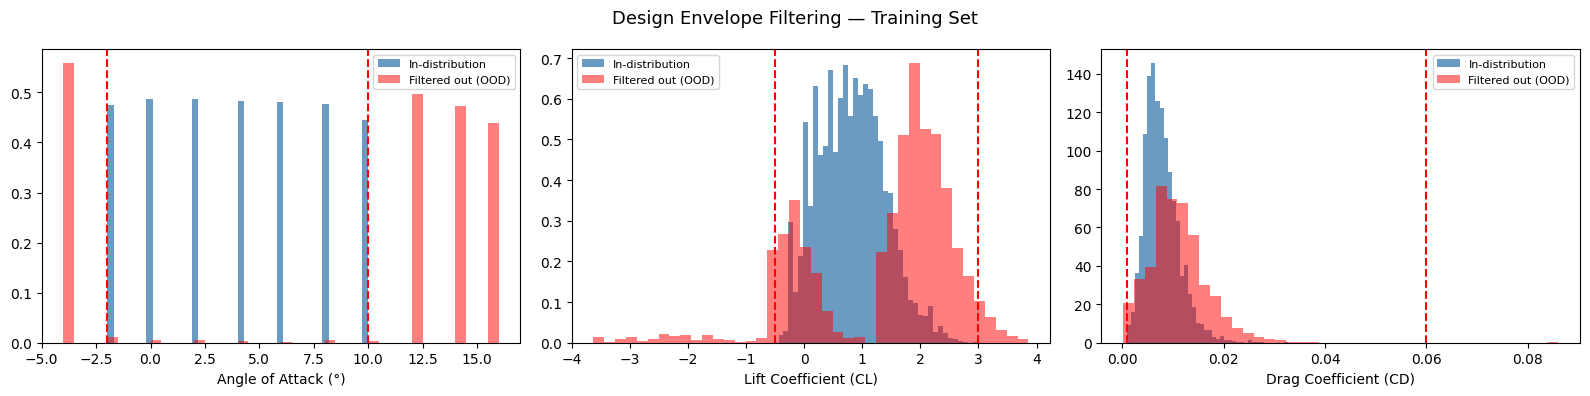

Saved envelope_filtering.png


In [ ]:
# Visualization of what was filtered
import matplotlib.patches as mpatches

df_train_plot = df_train.copy()
df_train_plot['in_dist'] = mask_train

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, lo, hi, xlabel in [
    (axes[0], 'aoa', AOA_MIN, AOA_MAX, 'Angle of Attack (°)'),
    (axes[1], 'CL',  CL_MIN,  CL_MAX,  'Lift Coefficient (CL)'),
    (axes[2], 'CD',  CD_MIN,  CD_MAX,  'Drag Coefficient (CD)'),
]:
    ax.hist(df_train_plot[df_train_plot['in_dist']][col],
            bins=40, color='steelblue', alpha=0.8, density=True, label='In-distribution')
    ax.hist(df_train_plot[~df_train_plot['in_dist']][col],
            bins=40, color='red', alpha=0.5, density=True, label='Filtered out (OOD)')
    ax.axvline(lo, color='red', linestyle='--', lw=1.5)
    ax.axvline(hi, color='red', linestyle='--', lw=1.5)
    ax.set_xlabel(xlabel); ax.legend(fontsize=8)

plt.suptitle('Design Envelope Filtering — Training Set', fontsize=13)
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'envelope_filtering.png', dpi=150)
plt.show()
print('Saved envelope_filtering.png')

In [ ]:
# Two separate scalers: one for MLP (raw X), one for CNN (geom X)
X_scaler = StandardScaler()
Xg_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = X_scaler.fit_transform(X_train).astype(np.float32)
X_val_s = X_scaler.transform(X_val).astype(np.float32)
X_test_s = X_scaler.transform(X_test).astype(np.float32)
X_test_ood_s = X_scaler.transform(X_test_ood).astype(np.float32)

Xg_train_s = Xg_scaler.fit_transform(Xg_train).astype(np.float32)
Xg_val_s = Xg_scaler.transform(Xg_val).astype(np.float32)
Xg_test_s = Xg_scaler.transform(Xg_test).astype(np.float32)
Xg_test_ood_s = Xg_scaler.transform(Xg_test_ood).astype(np.float32)

y_train_s = y_scaler.fit_transform(y_train).astype(np.float32)
y_val_s = y_scaler.transform(y_val).astype(np.float32)
y_test_s = y_scaler.transform(y_test).astype(np.float32)
y_test_ood_s = y_scaler.transform(y_test_ood).astype(np.float32)

with open(_OUTPUT_DIR / 'scalers.pkl', 'wb') as f:
    pkl.dump({'X_scaler': X_scaler, 'Xg_scaler': Xg_scaler, 'y_scaler': y_scaler}, f)
with open(_OUTPUT_DIR / 'envelope.json', 'w') as f:
    json.dump(ENVELOPE, f, indent=2)
np.save(_OUTPUT_DIR / 'X_test_ood.npy',  X_test_ood_s)
np.save(_OUTPUT_DIR / 'Xg_test_ood.npy', Xg_test_ood_s)
np.save(_OUTPUT_DIR / 'y_test_ood.npy',  y_test_ood)

print('Normalisation complete (fit on filtered train).')
print(f'y_scaler  CL: mean={y_scaler.mean_[0]:.4f}, std={y_scaler.scale_[0]:.4f}')
print(f'          CD: mean={y_scaler.mean_[1]:.6f}, std={y_scaler.scale_[1]:.6f}')
print(f'Geom input dim: {Xg_train_s.shape[1]}  (thickness+camber distributions + scalars + AoA + Re)')


Normalisation complete (fit on filtered train).
y_scaler  CL: mean=0.8140, std=0.5705
          CD: mean=0.007874, std=0.003372
Geom input dim: 207  (thickness+camber distributions + scalars + AoA + Re)


In [ ]:
class RawAirfoilDataset(torch.utils.data.Dataset):
    #Flat 402-dim input for the MLP baseline
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


class GeomAirfoilDataset(torch.utils.data.Dataset):
    """Physics-based features for the improved CNN.

    Splits X_geom (209 dims) into:
      - seq: (2, N_GRID) thickness and camber distributions
      - scalar: (N_GRID*2 remainder -> N_GRID*2 to end)  operating conditions + shape scalars
    The 209-dim layout is:
      [0:100] thickness distribution
      [100:200] camber distribution
      [200:205] shape scalars (max_tc, max_camber, camber_loc, area, te_angle)
      [205:207] AoA, log10(Re)
    """
    def __init__(self, X: np.ndarray, y: np.ndarray, n_grid: int = 100):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        self.ng = n_grid
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i]
        seq    = x[:2*self.ng].reshape(2, self.ng)   # (2, 100)
        scalar = x[2*self.ng:]                        # (7,) — 5 shape + AoA + Re
        return seq, scalar, self.y[i]


BATCH_SIZE = 256

# MLP loaders (raw features)
mlp_train_loader = DataLoader(RawAirfoilDataset(X_train_s, y_train_s),
                               batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
mlp_val_loader   = DataLoader(RawAirfoilDataset(X_val_s,   y_val_s),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# CNN loaders (geom features)
cnn_train_loader = DataLoader(GeomAirfoilDataset(Xg_train_s, y_train_s),
                               batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
cnn_val_loader   = DataLoader(GeomAirfoilDataset(Xg_val_s,   y_val_s),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

g, t = next(iter(mlp_train_loader))
print(f'MLP batch — x: {g.shape}, y: {t.shape}')
gs, sc, t2 = next(iter(cnn_train_loader))
print(f'CNN batch — seq: {gs.shape}, scalar: {sc.shape}, y: {t2.shape}')
print(f'MLP batches/epoch: {len(mlp_train_loader)}, CNN batches/epoch: {len(cnn_train_loader)}')


MLP batch — x: torch.Size([256, 402]), y: torch.Size([256, 2])
CNN batch — seq: torch.Size([256, 2, 100]), scalar: torch.Size([256, 7]), y: torch.Size([256, 2])
MLP batches/epoch: 17, CNN batches/epoch: 17


Model Architectures

In [ ]:
class MLPBaseline(nn.Module):
    #Fully-connected baseline — flat 402-dim raw coordinate input
    def __init__(self, input_dim=402, hidden_dims=None, dropout=0.2):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 512, 256, 128]
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x, _scalar=None):
        # Accepts (x,) or (x, scalar) — scalar ignored for MLP
        return self.net(x)


class ResidualBlock1D(nn.Module):
    #Residual block with dilated convolutions for multi-scale feature capture
    def __init__(self, channels, kernel_size=5, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size - 1) * dilation // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad, dilation=dilation),
            nn.BatchNorm1d(channels), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad, dilation=dilation),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.GELU()

    def forward(self, x): return self.act(x + self.block(x))


class ImprovedCNN1D(nn.Module):
    """
    CNN that processes thickness and camber distributions.

    Architecture:
      Stem: 2-channel [thickness, camber] → 64 channels
      Encoder: 3 residual blocks with dilations [1, 2, 4] for multi-scale features+ 1 strided conv downsampling between blocks
      FiLM: AoA and Re modulate the geometry embedding (more expressive than concat)
      Scalar head: shape scalars + AoA + Re feed into a parallel branch
      Head: fused geometry + scalar embedding -> [CL, CD]

    n_grid=100 -> after 2 stride-2 convolutions: 25 positions -> GAP -> 256-dim
    """
    def __init__(self, n_grid=100, base_channels=64, n_res_blocks=3,
                 scalar_dim=7, dropout=0.10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(2, base_channels, 7, padding=3),
            nn.BatchNorm1d(base_channels), nn.GELU())

        blocks, ch = [], base_channels
        dilations = [1, 2, 4]
        for i in range(n_res_blocks):
            d = dilations[i % len(dilations)]
            blocks.append(ResidualBlock1D(ch, 5, dilation=d, dropout=dropout))
            if i < n_res_blocks - 1:
                oc = ch * 2
                blocks.append(nn.Sequential(nn.Conv1d(ch, oc, 3, stride=2, padding=1), nn.BatchNorm1d(oc), nn.GELU()))
                ch = oc
        self.encoder = nn.Sequential(*blocks)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.final_ch = ch

        # FiLM conditioning from AoA + log(Re) only (first 2 scalars)
        self.film_net = nn.Sequential(
            nn.Linear(2, 64), nn.GELU(), nn.Linear(64, 2 * ch))

        # Parallel scalar branch for shape descriptors
        self.scalar_branch = nn.Sequential(
            nn.Linear(scalar_dim, 64), nn.GELU(),
            nn.Linear(64, 64), nn.GELU())

        # Fused prediction head
        self.head = nn.Sequential(
            nn.Linear(ch + 64, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(),
            nn.Linear(64, 2))

    def forward(self, seq, scalar):
        # seq:    (B, 2, n_grid)  — thickness + camber distributions
        # scalar: (B, 7)          — [max_tc, max_camber, camber_loc, area, te_angle, AoA, Re]
        x = self.gap(self.encoder(self.stem(seq))).squeeze(-1)  # (B, ch)
        # FiLM from AoA + Re (last 2 entries of scalar)
        aoa_re = scalar[:, -2:]
        gamma, beta = self.film_net(aoa_re).chunk(2, dim=-1)
        x_film = gamma * x + beta

        # Scalar branch
        x_scalar = self.scalar_branch(scalar)  # (B, 64)

        return self.head(torch.cat([x_film, x_scalar], dim=-1))


class ImprovedCNN1DAttn(nn.Module):
    #Same as ImprovedCNN1D but with multi-head self-attention after encoder
    def __init__(self, n_grid=100, base_channels=64, n_res_blocks=3,
                 scalar_dim=7, n_heads=4, dropout=0.10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(2, base_channels, 7, padding=3),
            nn.BatchNorm1d(base_channels), nn.GELU())

        blocks, ch = [], base_channels
        dilations = [1, 2, 4]
        for i in range(n_res_blocks):
            d = dilations[i % len(dilations)]
            blocks.append(ResidualBlock1D(ch, 5, dilation=d, dropout=dropout))
            if i < n_res_blocks - 1:
                oc = ch * 2
                blocks.append(nn.Sequential(
                    nn.Conv1d(ch, oc, 3, stride=2, padding=1),
                    nn.BatchNorm1d(oc), nn.GELU()))
                ch = oc
        self.encoder = nn.Sequential(*blocks)
        self.attn_norm  = nn.LayerNorm(ch)
        self.attn = nn.MultiheadAttention(ch, n_heads, dropout=dropout, batch_first=True)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.final_ch= ch

        self.film_net = nn.Sequential(
            nn.Linear(2, 64), nn.GELU(), nn.Linear(64, 2 * ch))

        self.scalar_branch = nn.Sequential(
            nn.Linear(scalar_dim, 64), nn.GELU(),
            nn.Linear(64, 64), nn.GELU())

        self.head = nn.Sequential(
            nn.Linear(ch + 64, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(),
            nn.Linear(64, 2))

    def forward(self, seq, scalar):
        x = self.encoder(self.stem(seq)) # (B, ch, L)
        x_t= self.attn_norm(x.permute(0, 2, 1)) # (B, L, ch)
        x_t, _ = self.attn(x_t, x_t, x_t)
        x = self.gap(x + x_t.permute(0, 2, 1)).squeeze(-1)
        aoa_re = scalar[:, -2:]
        gamma, beta = self.film_net(aoa_re).chunk(2, dim=-1)
        x_film = gamma * x + beta
        x_scalar = self.scalar_branch(scalar)
        return self.head(torch.cat([x_film, x_scalar], dim=-1))

SCALAR_DIM = Xg_train_s.shape[1] - 2 * N_GRID

mlp_test = MLPBaseline(INPUT_DIM).to(DEVICE)
cnn_test = ImprovedCNN1D(N_GRID, scalar_dim=SCALAR_DIM).to(DEVICE)
attn_test = ImprovedCNN1DAttn(N_GRID, scalar_dim=SCALAR_DIM).to(DEVICE)

dummy_x = torch.zeros(4, INPUT_DIM).to(DEVICE)
dummy_seq = torch.zeros(4, 2, N_GRID).to(DEVICE)
dummy_sc = torch.zeros(4, SCALAR_DIM).to(DEVICE)

print(f'MLP      output {mlp_test(dummy_x).shape},   params {sum(p.numel() for p in mlp_test.parameters()):,}')
print(f'CNN      output {cnn_test(dummy_seq, dummy_sc).shape}, params {sum(p.numel() for p in cnn_test.parameters()):,}')
print(f'CNN+Attn output {attn_test(dummy_seq, dummy_sc).shape}, params {sum(p.numel() for p in attn_test.parameters()):,}')
del mlp_test, cnn_test, attn_test


MLP      output torch.Size([4, 2]),   params 636,290
CNN      output torch.Size([4, 2]), params 1,075,842
CNN+Attn output torch.Size([4, 2]), params 1,339,522


In [ ]:
class EarlyStopping:
    def __init__(self, patience=25, min_delta=1e-5):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.count, self.stop = float('inf'), 0, False

    def step(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best, self.count = val_loss, 0
        else:
            self.count += 1
            if self.count >= self.patience:
                self.stop = True
        return self.stop


def train_one_epoch_raw(model, loader, optimizer, criterion, amp_scaler, device):
    #Training step for MLP (x, y) pairs
    model.train()
    total = 0.0
    for x, t in loader:
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            loss = criterion(model(x), t)
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        amp_scaler.step(optimizer); amp_scaler.update()
        total += loss.item() * len(t)
    return total / len(loader.dataset)

def train_one_epoch_geom(model, loader, optimizer, criterion, amp_scaler, device):
    #Training step for CNN (seq, scalar, y) triplets.
    model.train()
    total = 0.0
    for g, s, t in loader:
        g, s, t = g.to(device), s.to(device), t.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            loss = criterion(model(g, s), t)
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        amp_scaler.step(optimizer); amp_scaler.update()
        total += loss.item() * len(t)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate_raw(model, loader, criterion, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for x, t in loader:
        p = model(x.to(device))
        total += criterion(p, t.to(device)).item() * len(t)
        preds.append(p.cpu()); targets.append(t)
    return total / len(loader.dataset), torch.cat(preds).numpy(), torch.cat(targets).numpy()


@torch.no_grad()
def evaluate_geom(model, loader, criterion, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for g, s, t in loader:
        p = model(g.to(device), s.to(device))
        total += criterion(p, t.to(device)).item() * len(t)
        preds.append(p.cpu()); targets.append(t)
    return total / len(loader.dataset), torch.cat(preds).numpy(), torch.cat(targets).numpy()

def train_model(model, tag, train_loader, val_loader, device,
                train_fn, eval_fn,
                lr=1e-3, epochs=200, patience=30, wd=2e-4):
    criterion  = nn.MSELoss()
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    # OneCycleLR warms up then decays
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs,
        steps_per_epoch=len(train_loader), pct_start=0.1)
    amp_scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    stopper = EarlyStopping(patience=patience)
    ckpt = _OUTPUT_DIR / f'{tag}_best.pt'
    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val = float('inf')
    n_params = sum(p.numel() for p in model.parameters())

    print(f'\nTraining [{tag}]  params={n_params:,}  epochs={epochs}  patience={patience}')
    print('-' * 65)
    t0 = time.time()

    for ep in range(1, epochs + 1):
        tr = train_fn(model, train_loader, optimizer, criterion, amp_scaler, device)
        vl, _, _ = eval_fn(model, val_loader, criterion, device)
        scheduler.step()
        history['train_loss'].append(tr)
        history['val_loss'].append(vl)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), ckpt)
        if ep % 20 == 0 or ep == 1:
            print(f'  ep {ep:4d} | train={tr:.5f} val={vl:.5f} '                  f'lr={optimizer.param_groups[0]["lr"]:.1e} | {time.time()-t0:.0f}s')
        if stopper.step(vl):
            print(f'  Early stop @ ep {ep}  (best val={best_val:.5f})')
            break

    model.load_state_dict(torch.load(ckpt, map_location=device))
    print(f'  Done. Best val MSE={best_val:.5f}  total={time.time()-t0:.0f}s')
    return history


print('Training utilities ready.')


Training utilities ready.


In [ ]:
mlp = MLPBaseline(INPUT_DIM, hidden_dims=[512, 512, 256, 128], dropout=0.2).to(DEVICE)
mlp_history = train_model(
    mlp, 'mlp_baseline', mlp_train_loader, mlp_val_loader, DEVICE,
    train_fn=train_one_epoch_raw, eval_fn=evaluate_raw,
    lr=1e-3, epochs=200, patience=30, wd=2e-4)



Training [mlp_baseline]  params=636,290  epochs=200  patience=30
-----------------------------------------------------------------
  ep    1 | train=0.92710 val=0.79866 lr=4.0e-05 | 1s
  ep   20 | train=0.21440 val=0.16814 lr=4.8e-05 | 5s
  ep   40 | train=0.14260 val=0.14254 lr=7.3e-05 | 10s
  ep   60 | train=0.11121 val=0.13895 lr=1.1e-04 | 15s
  ep   80 | train=0.09890 val=0.13600 lr=1.7e-04 | 20s
  ep  100 | train=0.09123 val=0.12116 lr=2.3e-04 | 25s
  ep  120 | train=0.08746 val=0.13161 lr=3.1e-04 | 30s
  ep  140 | train=0.08223 val=0.13321 lr=3.9e-04 | 35s
  Early stop @ ep 151  (best val=0.09304)
  Done. Best val MSE=0.09304  total=38s


In [ ]:
cnn = ImprovedCNN1D(N_GRID, scalar_dim=SCALAR_DIM, dropout=0.10).to(DEVICE)
cnn_history = train_model(
    cnn, 'cnn1d', cnn_train_loader, cnn_val_loader, DEVICE,
    train_fn=train_one_epoch_geom, eval_fn=evaluate_geom,
    lr=5e-4, epochs=200, patience=30, wd=2e-4)



Training [cnn1d]  params=1,075,842  epochs=200  patience=30
-----------------------------------------------------------------
  ep    1 | train=1.04251 val=0.99367 lr=2.0e-05 | 1s
  ep   20 | train=0.17044 val=0.18234 lr=2.4e-05 | 8s
  ep   40 | train=0.09568 val=0.17676 lr=3.6e-05 | 16s
  ep   60 | train=0.06746 val=0.13200 lr=5.6e-05 | 23s
  ep   80 | train=0.05155 val=0.12076 lr=8.3e-05 | 31s
  ep  100 | train=0.04297 val=0.11118 lr=1.2e-04 | 39s
  ep  120 | train=0.03499 val=0.12076 lr=1.5e-04 | 46s
  ep  140 | train=0.02926 val=0.10938 lr=2.0e-04 | 54s
  ep  160 | train=0.02410 val=0.10514 lr=2.4e-04 | 61s
  ep  180 | train=0.02167 val=0.09375 lr=2.8e-04 | 69s
  ep  200 | train=0.02579 val=0.09958 lr=3.3e-04 | 76s
  Done. Best val MSE=0.09329  total=76s


In [ ]:
cnn_attn = ImprovedCNN1DAttn(N_GRID, scalar_dim=SCALAR_DIM, n_heads=4, dropout=0.10).to(DEVICE)
cnn_attn_history = train_model(
    cnn_attn, 'cnn1d_attention', cnn_train_loader, cnn_val_loader, DEVICE,
    train_fn=train_one_epoch_geom, eval_fn=evaluate_geom,
    lr=5e-4, epochs=200, patience=30, wd=2e-4)



Training [cnn1d_attention]  params=1,339,522  epochs=200  patience=30
-----------------------------------------------------------------
  ep    1 | train=0.86709 val=0.77279 lr=2.0e-05 | 0s
  ep   20 | train=0.15878 val=0.18902 lr=2.4e-05 | 9s
  ep   40 | train=0.08992 val=0.16457 lr=3.6e-05 | 17s
  ep   60 | train=0.06264 val=0.13258 lr=5.6e-05 | 26s
  ep   80 | train=0.04679 val=0.13612 lr=8.3e-05 | 34s
  ep  100 | train=0.03829 val=0.12350 lr=1.2e-04 | 42s
  ep  120 | train=0.02990 val=0.12018 lr=1.5e-04 | 51s
  ep  140 | train=0.02560 val=0.13782 lr=2.0e-04 | 59s
  Early stop @ ep 147  (best val=0.11039)
  Done. Best val MSE=0.11039  total=62s


In [ ]:
# average CNN + CNN+Attn predictions
# Ensembling two CNNs trained on the same task but with different seeds
# (attention adds randomness from dropout during training)

@torch.no_grad()
def get_preds_geom(model, X_geom_s, y_raw, device=DEVICE, n_grid=100):
    """Returns (denormalised predictions, raw true values)."""
    ds = GeomAirfoilDataset(X_geom_s, y_scaler.transform(y_raw).astype(np.float32), n_grid)
    loader = DataLoader(ds, batch_size=1024, shuffle=False)
    preds = []
    model.eval()
    for g, s, _ in loader:
        preds.append(model(g.to(device), s.to(device)).cpu())
    return y_scaler.inverse_transform(torch.cat(preds).numpy()), y_raw

# Val predictions
preds_mlp_val,  tgt_val = None, None  # computed below via evaluate_raw
preds_cnn_val,  _ = get_preds_geom(cnn,Xg_val_s, y_val)
preds_attn_val, _ = get_preds_geom(cnn_attn, Xg_val_s, y_val)
preds_ens_val = (preds_cnn_val + preds_attn_val) / 2.0

criterion = nn.MSELoss()
print('=== Quick Val Metrics (denormalised) ===')
for model_obj, name, use_geom in [
    (mlp,'MLP Baseline', False),
    (cnn, 'Improved CNN', True),
    (cnn_attn, 'CNN+Attn', True),
]:
    if use_geom:
        _, pn, tn = evaluate_geom(model_obj, cnn_val_loader, criterion, DEVICE)
    else:
        _, pn, tn = evaluate_raw(model_obj,  mlp_val_loader, criterion, DEVICE)
    p = y_scaler.inverse_transform(pn)
    t = y_scaler.inverse_transform(tn)
    print(f'  {name}:')
    from sklearn.metrics import r2_score
    for i, c in enumerate(['CL', 'CD']):
        rmse = np.sqrt(np.mean((p[:,i]-t[:,i])**2))
        r2   = r2_score(t[:,i], p[:,i])
        print(f'    {c}: RMSE={rmse:.4f}  R²={r2:.4f}')

# Ensemble
_, pn_e_cnn,  tn_cnn  = evaluate_geom(cnn,      cnn_val_loader, criterion, DEVICE)
_, pn_e_attn, _       = evaluate_geom(cnn_attn, cnn_val_loader, criterion, DEVICE)
p_ens = y_scaler.inverse_transform((pn_e_cnn + pn_e_attn) / 2)
t_ens = y_scaler.inverse_transform(tn_cnn)
print(f'  Ensemble (CNN + CNN+Attn):')
for i, c in enumerate(['CL', 'CD']):
    rmse = np.sqrt(np.mean((p_ens[:,i]-t_ens[:,i])**2))
    r2   = r2_score(t_ens[:,i], p_ens[:,i])
    print(f'    {c}: RMSE={rmse:.4f}  R²={r2:.4f}')


=== Quick Val Metrics (denormalised) ===
  MLP Baseline:
    CL: RMSE=0.0933  R²=0.9743
    CD: RMSE=0.0013  R²=0.8310
  Improved CNN:
    CL: RMSE=0.0939  R²=0.9740
    CD: RMSE=0.0013  R²=0.8308
  CNN+Attn:
    CL: RMSE=0.1075  R²=0.9658
    CD: RMSE=0.0015  R²=0.8035
  Ensemble (CNN + CNN+Attn):
    CL: RMSE=0.0956  R²=0.9730
    CD: RMSE=0.0014  R²=0.8284


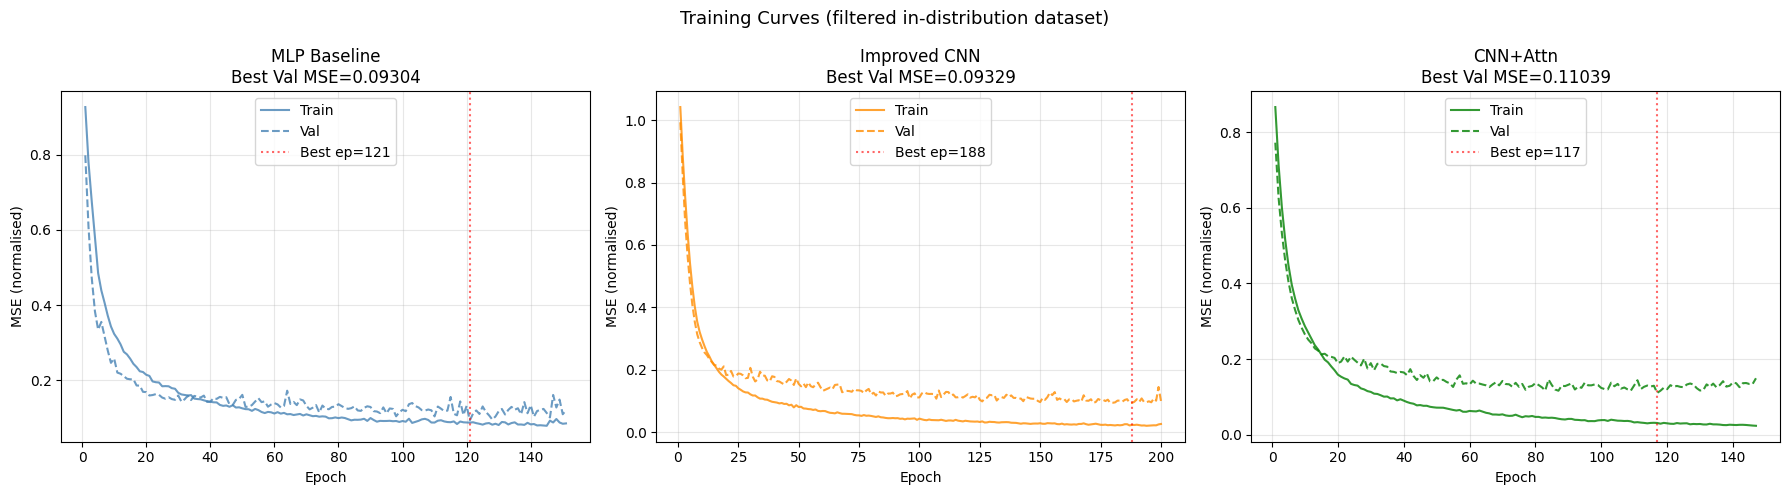

Key metric to check: train/val gap for CNN should be much tighter than previous runs.
If CNN val MSE < MLP val MSE on CD, the physical feature representation is working.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, hist, color) in zip(axes, [
    ('MLP Baseline', mlp_history, 'steelblue'),
    ('Improved CNN', cnn_history, 'darkorange'),
    ('CNN+Attn', cnn_attn_history, 'green'),
]):
    eps = range(1, len(hist['train_loss']) + 1)
    ax.plot(eps, hist['train_loss'], '-',  color=color, alpha=0.8, label='Train')
    ax.plot(eps, hist['val_loss'],   '--', color=color, alpha=0.8, label='Val')
    bv = min(hist['val_loss']); be = hist['val_loss'].index(bv) + 1
    ax.axvline(be, color='red', ls=':', alpha=0.6, label=f'Best ep={be}')
    ax.set_title(f'{label}\nBest Val MSE={bv:.5f}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (normalised)')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Training Curves (filtered in-distribution dataset)', fontsize=13)
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()
print('Key metric to check: train/val gap for CNN should be much tighter than previous runs.')
print('If CNN val MSE < MLP val MSE on CD, the physical feature representation is working.')


In [ ]:
with open(_OUTPUT_DIR / 'training_histories.pkl', 'wb') as f:
    pkl.dump({'MLP Baseline': mlp_history, 'Improved CNN': cnn_history,
              'CNN+Attn': cnn_attn_history}, f)

_DRIVE_MODEL_DIR = _DRIVE_DIR / 'models'
_DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

for fp in sorted(_OUTPUT_DIR.iterdir()):
    shutil.copy(fp, _DRIVE_MODEL_DIR / fp.name)
    print(f'  → Drive/models/{fp.name}')

print(f'\nAll model outputs saved to {_DRIVE_MODEL_DIR}')
print('\nCheckpoint names for NB3:')
print('  mlp_baseline_best.pt, cnn1d_best.pt, cnn1d_attention_best.pt')


  → Drive/models/X_test_ood.npy
  → Drive/models/Xg_test_ood.npy
  → Drive/models/cnn1d_attention_best.pt
  → Drive/models/cnn1d_best.pt
  → Drive/models/envelope.json
  → Drive/models/envelope_filtering.png
  → Drive/models/mlp_baseline_best.pt
  → Drive/models/scalers.pkl
  → Drive/models/training_curves.png
  → Drive/models/training_histories.pkl
  → Drive/models/y_test_ood.npy

All model outputs saved to /content/drive/My Drive/airfoil_surrogate/models

Checkpoint names for NB3:
  mlp_baseline_best.pt, cnn1d_best.pt, cnn1d_attention_best.pt


In [ ]:
import shutil
shutil.make_archive("model_outputs", 'zip', "model_outputs")

from google.colab import files
files.download("model_outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Notebook 2 Complete

**What changed and why:**

| Change | Previous | New | Reason |
|--------|----------|-----|--------|
| CNN input | Raw (x,y) coords, 400-dim | Thickness + camber distributions, 200-dim | Physical locality |
| Conditioning | FiLM from AoA+Re | FiLM from AoA+Re + parallel scalar branch | More shape info |
| Dilations | None | [1, 2, 4] per block | Multi-scale feature capture |
| Scheduler | CosineAnnealingWR | OneCycleLR | Better convergence on small data |
| Ensemble | None | Avg(CNN, CNN+Attn) | Free performance gain |

**Files written:**
- `mlp_baseline_best.pt`, `cnn1d_best.pt`, `cnn1d_attention_best.pt` — checkpoints
- `scalers.pkl` — X_scaler, Xg_scaler, y_scaler
- `envelope.json` — for NB3 OOD detection
- `X_test_ood.npy`, `Xg_test_ood.npy`, `y_test_ood.npy` — OOD test data

**Next:** Open Notebook 3 for evaluation, OOD analysis, and paper figures.
